In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import scipy
from scipy.signal import find_peaks, welch
import pandas as pd
from pandas.plotting import parallel_coordinates
import sklearn
from sklearn.cluster import KMeans
from collections import Counter
from lib.readwav import *

# Estrapolazione e salvataggio delle armoniche nelle note prodotte dall'organo


In [2]:
# Funzione per la stima più precisa della fondamentale:

def f0_MCD(frequencies_of_peaks, highest_candidate):
    lowest_candidate = np.min(frequencies_of_peaks) / 3
    candidates = np.arange(highest_candidate, lowest_candidate-0.1, -0.1)
    lowest_residual = float("inf")
    best_f0 = highest_candidate

    for f0 in candidates:
        ratios = frequencies_of_peaks / f0
        integers = np.round(ratios)
        if np.any(integers == 0):
            continue
        discrepancies = np.abs(ratios - integers)
        residual = np.sum(discrepancies)
        found_harmonics = len(np.unique(integers))
        max_harmonic = np.max(integers)
        missed_harmonics = max_harmonic - found_harmonics
        residual += missed_harmonics * 0.3
        if residual < (lowest_residual * 0.90):
            lowest_residual = residual
            best_f0 = f0
    
    return best_f0

In [3]:
# Ciclo per estrapolazione su tutti i file:

fundamentals = [] # Array contenente le sole fondamentali per ciascun file
harmonics = [] # Lista contenente le armoniche: ogni riga è un file, ogni colonna un'armonica (inclusa la fondamentale)
power_spectra = [] # Lista contenente gli spettri valutati nelle frequenze delle armoniche
normalized_power_spectra = [] # Lista contenente sempre gli spettri valutati, ma ora anche divisi per la potenza della fondamentale

for file in range(280):
    print("È in corso l'analisi del file",file+1,"...")
    
    # Lettura file:
    filename = "./wav_files/note_{}.wav".format(file+1)
    rate, note = readwav(filename)
    note = note[:,0]
    time = np.linspace(0, note.shape[0], note.shape[0], endpoint = False) / rate
    first_15 = time[0] + 0.15 * (time[-1] - time[0])
    last_5 = time[0] + 0.95 * (time[-1] - time[0])
    cut = (time >= first_15) & (time <= last_5)
    time = time[cut]
    note = note[cut]
   
    # Calcolo preventivo della fondamentale:
    width = (time[-1] - time[0]) / 10
    gaussian_window = scipy.signal.windows.gaussian(int(width * rate), std = 0.2 * rate) # 0.2s => 9600 , oppure int(width * rate / 6)
    
    ############ Perché funziona solo con sigma fissa? centra con l'uniformare la risoluzione?
    
    frequencies, spectrum = welch(note, fs = rate, window = gaussian_window, nperseg = len(gaussian_window))
    spectrum = 10 * np.log10(spectrum)
    peaks, _ = find_peaks(spectrum, prominence = 25)
    index_of_max = np.argmax(spectrum[peaks])
    previsional_frequency = frequencies[peaks[index_of_max]]    

    # Calcolo più preciso della fondamentale:
    frequencies_of_peaks = frequencies[peaks]
    frequencies_of_peaks = frequencies_of_peaks[:8]
    fundamental = f0_MCD(frequencies_of_peaks, previsional_frequency)

    # Calcolo delle 5 armoniche successive:
    estimated_harmonics = [fundamental * i for i in range(1,7)]
    measured_harmonics_frequency = []
    measured_harmonics_power = []
    log_frequencies = np.log10(frequencies + 1.e-6)
    log_peaks = np.log10(frequencies_of_peaks)
    log_tolerance = 0.03
    for estimate in estimated_harmonics:
        log_harmonic = np.log10(estimate)
        distances = np.abs(log_peaks - log_harmonic)
        if np.any(distances < log_tolerance):
            index_target = peaks[np.argmin(distances)]
            measured_harmonics_frequency.append(frequencies[index_target])
            measured_harmonics_power.append(spectrum[index_target])
        else:
            distances = np.abs(log_frequencies - log_harmonic)
            index_target = np.argmin(distances)
            measured_harmonics_frequency.append(frequencies[index_target])
            measured_harmonics_power.append(spectrum[index_target])

    # Aggiornamento degli array di scope globale:
    fundamentals.append(fundamental)
    harmonics.append(measured_harmonics_frequency)
    power_spectra.append(measured_harmonics_power)
    normalized_power_spectra.append(measured_harmonics_power - measured_harmonics_power[0])

print("\n\nFinito!")

È in corso l'analisi del file 1 ...
È in corso l'analisi del file 2 ...
È in corso l'analisi del file 3 ...
È in corso l'analisi del file 4 ...
È in corso l'analisi del file 5 ...
È in corso l'analisi del file 6 ...
È in corso l'analisi del file 7 ...
È in corso l'analisi del file 8 ...
È in corso l'analisi del file 9 ...
È in corso l'analisi del file 10 ...
È in corso l'analisi del file 11 ...
È in corso l'analisi del file 12 ...
È in corso l'analisi del file 13 ...
È in corso l'analisi del file 14 ...
È in corso l'analisi del file 15 ...
È in corso l'analisi del file 16 ...
È in corso l'analisi del file 17 ...
È in corso l'analisi del file 18 ...
È in corso l'analisi del file 19 ...
È in corso l'analisi del file 20 ...
È in corso l'analisi del file 21 ...
È in corso l'analisi del file 22 ...
È in corso l'analisi del file 23 ...
È in corso l'analisi del file 24 ...
È in corso l'analisi del file 25 ...
È in corso l'analisi del file 26 ...
È in corso l'analisi del file 27 ...
È in corso

In [4]:
# Salvataggio su file esterni:
np.savetxt("fundamentals.csv", fundamentals, delimiter = ",")
np.savetxt("harmonics.csv", harmonics, delimiter = ",")
np.savetxt("power_spectra.csv", power_spectra, delimiter = ",")
np.savetxt("normalized_power_spectra.csv", normalized_power_spectra, delimiter = ",")

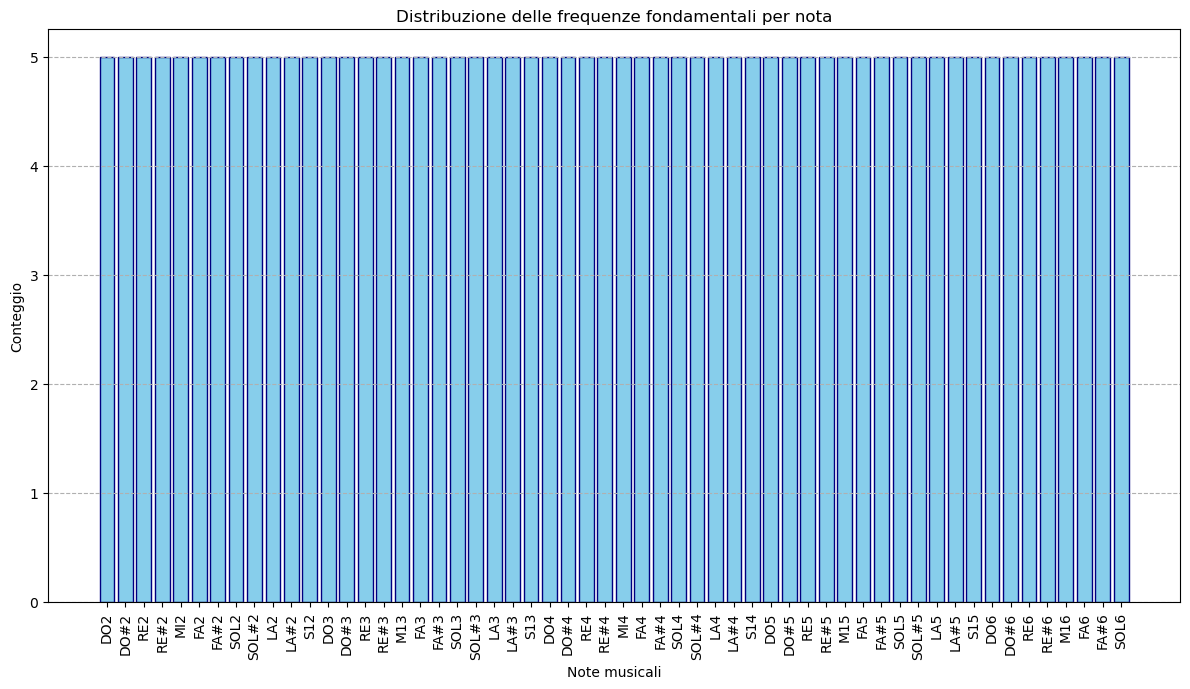


Ci sono in totale 56 note diverse



In [2]:
# Questa cella è un test per verificare che le note identificate siano distribuite come ci aspettiamo.


# Carichiamo la classificazione di riferimento:
musical_notes = {} # Come dizionario, dove salveremo sia nome che frequenza
with open("note_musicali.csv", "r") as f:
    for line in f:
        name, frequency = line.strip().split(",")
        musical_notes[name] = float(frequency)
names = list(musical_notes.keys()) # Salviamo tutti i nomi in un array
ref_frequencies = np.array(list(musical_notes.values())) # e tutte le frequenze di riferimento in un altro array

# Carichiamo le nostre stime delle fondamentali:
data = np.loadtxt("fundamentals.csv")

# Per associare la nota più vicina, non facciamo un banale abs perché la scala delle frequenze di riferimento è logaritmica,
# non lineare. Per questo, passiamo prima alle scale logaritmiche, e poi controlliamo la vicinanza:
ref_frequencies = np.log2(ref_frequencies)
measured_names = [ names[(np.abs(np.log2(fundamental) - ref_frequencies)).argmin()] for fundamental in data ]

# Ordiniamo il grafico secondo l'ordine del 
c = Counter(measured_names) # Counter è un oggetto: per ciascun elemento dell'array, associa il numero di istanze
sorted_notes = sorted(musical_notes.keys(), key=lambda x: musical_notes[x]) # Leggiamo e salviamo l'ordine dei nomi delle note
labels = [n for n in sorted_notes if n in c] # Salviamo dentro labels le note nell'ordine giusto
values = [c[n] for n in labels] # Salviamo in values le istanze delle labels, nonché delle note

# Grafichiamo l'istogramma: il nostro indizio è che NESSUNA COLONNA SUPERI 5
plt.figure(figsize=(12, 7))
plt.bar(labels, values, color="skyblue", edgecolor="navy")
plt.xlabel("Note musicali")
plt.ylabel("Conteggio")
plt.title("Distribuzione delle frequenze fondamentali per nota")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--")
plt.tight_layout()
plt.show()

number_of_notes = len(np.unique(labels))
print("\nCi sono in totale", number_of_notes, "note diverse\n")

In [3]:
# Piccolo test per capire quali file corrispondono a quale colonna di note:
# per una frequenza X, estrapoliamo le note che cadono nel bin di X.
X = 392
belonging_indexes = np.where(((np.log2(X)-1/24) < np.log2(data)) & (np.log2(data) < (np.log2(X)+1/12)))
print("La frequenza", X, "è la fondamentale dei file", belonging_indexes[0] + 1) 

La frequenza 392 è la fondamentale dei file [ 94 101 150 193 211 254]


In [16]:
# Ora è il tempo di fare Kmeans clustering!

data = np.loadtxt("normalized_power_spectra.csv", delimiter=",")
# Sarà necessario all'algoritmo lavorare con quantità normalizzate, che è il motivo per cui le abbiamo salvate in primo luogo.
# In particolare, data sarà in scala logaritmica e avrà unità di misura decibel, nel senso che ad esempio
# un'armonica di valore -20 vuol dire che è 20dB meno intensa rispetto alla fondamentale.

# Nota inoltre che data è una matrice: ogni riga è una nota, ogni colonna un'armonica.
# Questo, in termini teorici, vuol dire che avremo 280 samples, ciascuno con 6 features.

# Il secondo e ultimo indizio a nostra disposizione è che il numero di clusters è prefissato a 5. Facciamo girare l'algoritmo:
kmeans = KMeans(n_clusters = 5,
                init = "random",
                n_init = 10000,
                copy_x = True,
                algorithm = "lloyd").fit(data)
# Concettualmente, dato che conosciamo in anticipo il numero di clusters stiamo rimuovendo un grosso grado di libertà.
# Per questo motivo, possiamo invece concentrare tutta la computazione sul numero di run: l'algoritmo viene eseguito
# n_init volte e vengono restituiti i valori migliori. Nota che scegliendo n_init più grandi di 10000 non si vedono miglioramenti.

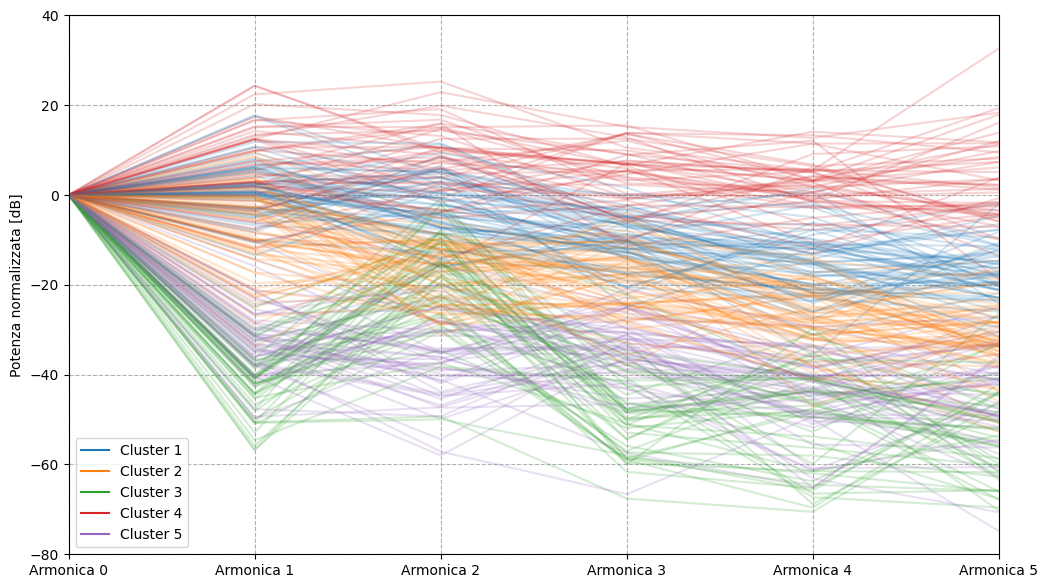

In [17]:
# Grafichiamo i risultati in una cella diversa:
columns = [f"Armonica {i}" for i in range(6)]
database = pd.DataFrame(data, columns=columns) # Come una matrice multidimensionale di dati
database["Cluster"] = kmeans.labels_ # Aggiungiamo un field in cui salviamo l'associazione ad un cluster

# Per scegliere il colore con cui viene rappresentato ciascun cluster serve un po' di tedioso olio di gomito:
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(5)]
manual_selection = {i: colors[i] for i in range(5)}
handles = [
    mlines.Line2D([], [], color=manual_selection[0], label="Cluster 1"),
    mlines.Line2D([], [], color=manual_selection[1], label="Cluster 2"),
    mlines.Line2D([], [], color=manual_selection[2], label="Cluster 3"),
    mlines.Line2D([], [], color=manual_selection[3], label="Cluster 4"),
    mlines.Line2D([], [], color=manual_selection[4], label="Cluster 5")
]

# Ora possiamo graficare con molta libertà di personalizzazione:
plt.figure(figsize=(12, 7))
for _, row in database.iterrows():
    plt.plot(columns, row[columns], color=manual_selection[row["Cluster"]], alpha=0.2)
plt.margins(x=0)
plt.legend(handles=handles)
plt.ylabel("Potenza normalizzata [dB]")
plt.ylim(-80, 40)
plt.grid(linestyle="--")
plt.show()

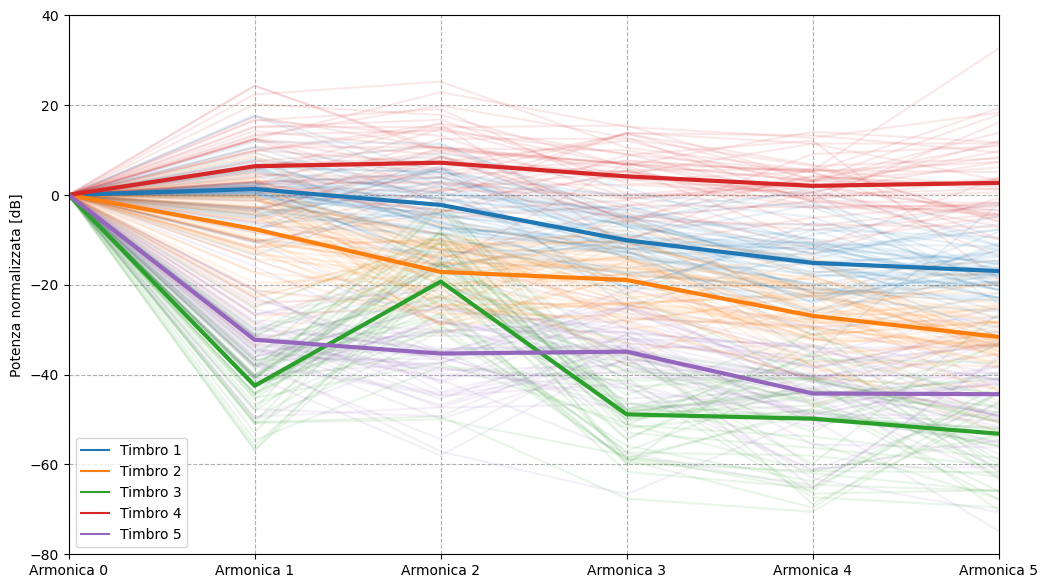

In [18]:
# Il grafico sopra mostra tutte le note, raggruppate per colore, dove ogni colore è un cluster.
# Concettualmente, vorremmo fare la media di tutti gli andamenti di ciascun cluster, per vedere l'effetto del timbro associato.

# Chiediamo al sampler dove sono i centri dei cluster:
centroids = kmeans.cluster_centers_ # Questa sarà una matrice in cui ogni riga è un cluster e ogni colonna è una feature (armonica)
db_centroids = pd.DataFrame(centroids, columns=columns)
db_centroids["Timbro"] = [0, 1, 2, 3, 4]
# Invece di aggiungere il field di appartenenza, aggiungiamo il field nome del timbro

handles = [
    mlines.Line2D([], [], color=manual_selection[0], label="Timbro 1"),
    mlines.Line2D([], [], color=manual_selection[1], label="Timbro 2"),
    mlines.Line2D([], [], color=manual_selection[2], label="Timbro 3"),
    mlines.Line2D([], [], color=manual_selection[3], label="Timbro 4"),
    mlines.Line2D([], [], color=manual_selection[4], label="Timbro 5")
]

plt.figure(figsize=(12, 7))
for _, row in database.iterrows():
    plt.plot(columns, row[columns], color=manual_selection[row["Cluster"]], alpha=0.1)
for _, row in db_centroids.iterrows():
    plt.plot(columns, row[columns], color=manual_selection[row["Timbro"]], linewidth=3)
plt.margins(x=0)
plt.legend(handles=handles)

#ax2 = parallel_coordinates(db_centroids, "Timbro", color=plt.cm.tab10.colors[:5], linewidth=3)

plt.ylabel("Potenza normalizzata [dB]")
plt.ylim(-80, 40)
plt.grid(linestyle="--")
plt.show()

Il cluster 1 contiene 61 note
Il cluster 2 contiene 66 note
Il cluster 3 contiene 47 note
Il cluster 4 contiene 51 note
Il cluster 5 contiene 55 note


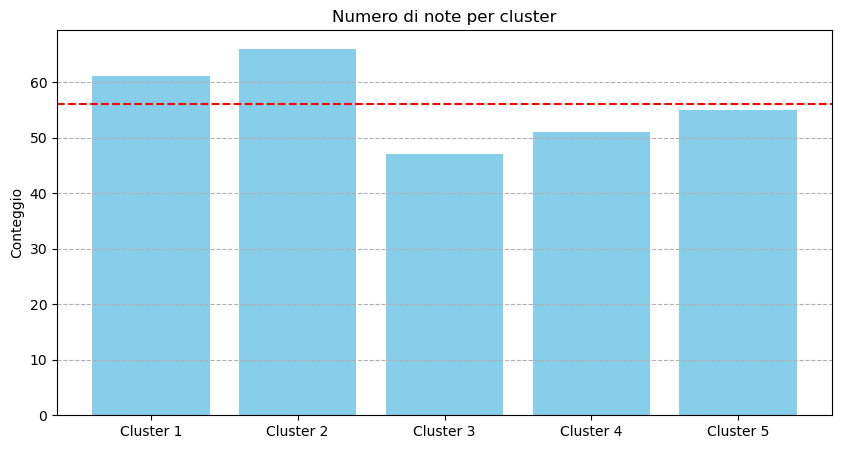

In [19]:
# Nota che il numero totale di note trovate è (almeno) 56, e sapendo che non ci sono ripetizioni in alcun cluster
# ci aspettiamo che ogni cluster contenga (almeno) 56 note. Verifichiamolo:

counts = []
for cluster in range(5):
    n = np.sum(kmeans.labels_ == cluster)
    counts.append(n)
    print(f"Il cluster {cluster+1} contiene {n} note")

plt.figure(figsize=(10, 5))
plt.bar(range(5), counts, tick_label=[f"Cluster {i+1}" for i in range(5)], color="skyblue")
plt.axhline(number_of_notes, color="r", linestyle="--")
plt.title("Numero di note per cluster")
plt.ylabel("Conteggio")
plt.grid(axis="y", linestyle="--")
plt.show()

Il cluster 1 contiene in media 57.41 note
Il cluster 2 contiene in media 54.46 note
Il cluster 3 contiene in media 56.52 note
Il cluster 4 contiene in media 56.01 note
Il cluster 5 contiene in media 55.6 note


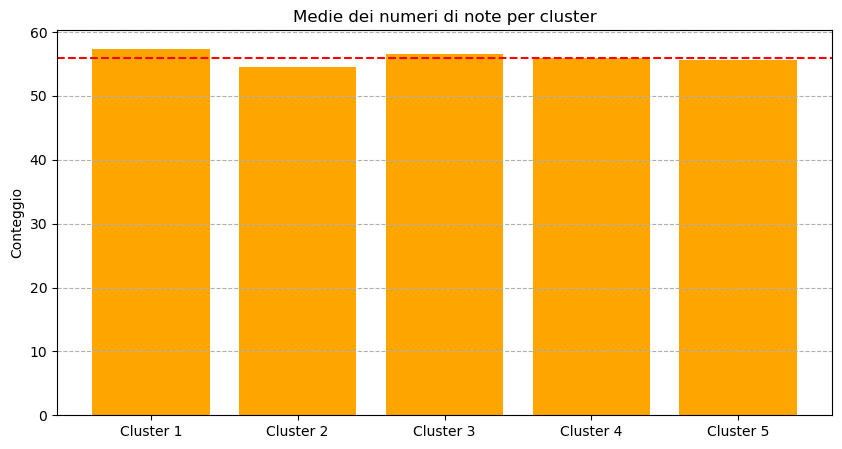

In [26]:
# Proviamo a ripetere l'analisi col kmeans tante volte, così da alla fine fare un istogramma con la media
# del numero di note trovato per cluster, invece che quello di "una sola iterazione".

number_of_iterations = 100
counters = np.zeros((number_of_iterations, 5), dtype=int)
for i in range(number_of_iterations):
    kmeans = KMeans(n_clusters = 5,
                    init = "random",
                    n_init = 1000, # Abbassiamo per rendere la computazione sostenibile
                    copy_x = True,
                    algorithm = "lloyd").fit(data)
    for cluster in range(5):
        counters[i][cluster] = np.sum(kmeans.labels_ == cluster)
average_bins = np.mean(counters, axis=0)

for i in range(5):
    print(f"Il cluster {i+1} contiene in media {average_bins[i]} note")

plt.figure(figsize=(10, 5))
plt.bar(range(5), average_bins, tick_label=[f"Cluster {i+1}" for i in range(5)], color="orange")
plt.axhline(number_of_notes, color="r", linestyle="--")
plt.title("Medie dei numeri di note per cluster")
plt.ylabel("Conteggio")
plt.grid(axis="y", linestyle="--")
plt.show()